# Time Varying Filter based EMD (TVF-EMD)

**TVF-EMD** (Li, Li & Mo, 2017) keeps EMD's recursive “peel the local high-frequency
part, leave the residual” structure, but **replaces cubic-spline envelope sifting
with a time-varying B-spline filter**.  Instantaneous amplitude / frequency of the
current residual are used to estimate a **bisecting cut-off** $\varphi'_\mathrm{bis}(t)$;
knots of the filter are the extrema of $h(t)=\cos\int\varphi'_\mathrm{bis}$.  A
cut-off **realignment** step (`anti_modemixing`) repairs intermittency, which is
the main source of mode mixing in classical EMD.

The stopping criterion is also different: an IMF is a **local narrow-band** signal
(Loughlin bandwidth ratio $\theta(t)\le\xi$), not a signal whose upper and lower
envelopes are forced to be symmetric.  That makes the method more stable at low
sampling rates.

The last returned row is the residual, so IMF rows sum back to the input.

**Reference**

> H. Li, Z. Li, W. Mo.  
> *A time varying filter approach for empirical mode decomposition.*  
> Signal Processing, 138:146–158, 2017.  
> https://doi.org/10.1016/j.sigpro.2017.03.019

MATLAB: `repo/tvfemd/tvf_emd.m` (File Exchange). This notebook uses `pysdkit.TVF_EMD`.


## 1. Imports

In [7]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import TVF_EMD, EMD
from pysdkit.plot import plot_IMFs, plot_IMFs_amplitude_spectra

plt.rcParams["figure.dpi"] = 120
print(TVF_EMD())

Time Varying Filter based Empirical Mode Decomposition (TVF_EMD)


## 2. Algorithm principles

### 2.1 What classical EMD does, and where it fails

EMD (Huang *et al.*, 1998) decomposes a real signal as

$$
x(t)=\sum_{i=1}^{N}\mathrm{imf}_i(t)+r(t). \tag{1}
$$

Sifting estimates a **local mean** $m(t)$ as the average of cubic-spline envelopes
through maxima and minima, then peels $h\leftarrow h-m$ until $h$ satisfies the
two IMF conditions: (i) extrema and zero-crossings differ by at most one;
(ii) the local average of the envelopes is zero (Algorithm 1 of the paper).

Li *et al.* isolate two failure modes that both produce **mode mixing**:

1. **Separation problem.**  EMD cannot reliably split two tones whose frequency
   ratio lies within about one octave (cut-off $\approx 0.65$).
2. **Intermittence problem.**  Sparse high-frequency bursts (or noise) corrupt
   the extrema that define the envelopes, so a slow carrier is chopped across IMFs.

Condition (ii) is also **too rigid** on sampled data: even a clean
narrow-band oscillation need not have symmetric envelopes at low sampling rates
(Rilling; the paper notes $\sim 5\times$ Nyquist is often required).  SD / 3-threshold
stopping rules do not use bandwidth information.

TVF-EMD's answer: treat local-mean estimation as **time-varying low-pass
filtering**, stop when the residual is **local narrow-band**, and *realign* the
cut-off where intermittency is detected.

### 2.2 B-spline approximation as a time-varying filter

For uniform knot spacing $m$ and spline order $n$, Unser *et al.* write the
approximant as

$$
g_m^n(t)=\sum_{k}c(k)\,\beta^n(t/m-k)
=[p_m^n*x]_{\downarrow m}*b_m^n(t), \tag{2--6}
$$

i.e. pre-filter $\to$ decimate by $m$ $\to$ post-filter.  The frequency response
approaches an ideal low-pass as $n$ grows, and the **cut-off is $1/(2m)$** — so
the knot spacing *is* the cut-off.  For **non-uniform** knots the same construction
behaves as a TVF: the local cut-off follows the local knot density (Yang; paper
Fig. 2, noisy chirp recovered from extrema of the clean signal).

PySDKit / MATLAB default `bsp_order=26` (File Exchange).  The paper uses $n=28$
in experiments; larger $n$ steepens the roll-off.

### 2.3 Local cut-off from instantaneous amplitude and frequency

Write the analytic signal $z(t)=A(t)\,e^{j\varphi(t)}$ via the Hilbert transform
(paper eq. 10).  Any multi-component $x$ can be recast as **two** AM–FM parts

$$
z(t)=a_1(t)\,e^{j\varphi_1(t)}+a_2(t)\,e^{j\varphi_2(t)}, \tag{14}
$$

chosen so that $a_1,a_2$ and $\varphi'_1,\varphi'_2$ vary as slowly as possible
(local narrow-band).  Then (eqs. 15–16)

$$
A^2=a_1^2+a_2^2+2a_1 a_2\cos(\varphi_1-\varphi_2).
$$

If the amplitudes vary slower than the beat $\cos(\varphi_1-\varphi_2)$, extrema of
$A$ occur where that cosine is $\pm 1$.  Define the slow envelopes of $A$

$$
\beta_1(t)\approx\text{interp of }A(t_{\min}),\qquad
\beta_2(t)\approx\text{interp of }A(t_{\max}), \tag{25--26}
$$

whence (assuming $a_1\ge a_2$)

$$
a_1=\frac{\beta_1+\beta_2}{2},\qquad
a_2=\frac{\beta_2-\beta_1}{2}. \tag{27}
$$

Interpolating $\varphi' A^2$ at the same extrema gives $\eta_1,\eta_2$ (eq. 29);
solving the linear system (eq. 28) yields $\varphi'_1$ and $\varphi'_2$ (eq. 30).
The **bisecting frequency** used as TVF cut-off is

$$
\varphi'_\mathrm{bis}(t)
=\frac{\varphi'_1(t)+\varphi'_2(t)}{2}
=\frac{\eta_2(t)-\eta_1(t)}{4\,a_1(t)\,a_2(t)}. \tag{31}
$$

Knots of the B-spline filter are the extrema of the unit-amplitude FM

$$
h(t)=\cos\int\varphi'_\mathrm{bis}(t)\,dt, \tag{32}
$$

so the local cut-off of $m(t)$ tracks $\varphi'_\mathrm{bis}(t)$.  Subtracting
$m$ peels the **local higher-frequency (LHF)** part and leaves the **local
lower-frequency (LLF)** residual.

This analytic cut-off is why closely spaced tones (the paper's 24 Hz / 36 Hz
class of examples) separate better than cubic-spline EMD, which only “sees”
extrema timing, not an estimated mid-frequency.

### 2.4 Cut-off realignment (intermittence / mode mixing)

If a burst of LHF energy appears only on some intervals, $\varphi'_\mathrm{bis}$
jumps between a floor and a peak and the LLF carrier is **segmented** (paper
Fig. 3c–d).  Algorithm 2 realigns the cut-off **before** filtering:

1. Locate maxima $u_i$ of the current signal.
2. Declare an intermittence $e_j=u_i$ when, on $[u_i,u_{i+1}]$,

$$
\frac{\max\varphi'_\mathrm{bis}-\min\varphi'_\mathrm{bis}}
{\min\varphi'_\mathrm{bis}}>\rho,\qquad \rho=0.25. \tag{Alg. 2}
$$

   Rising edge $\Rightarrow$ the floor is to the **left**; falling edge $\Rightarrow$
   to the **right**.
3. Zero (ignore) the floor segments and **interpolate across the peaks**.

`TVF_EMD._anti_mode_mixing` is this step (applied twice, as in MATLAB).
Noise-assisted EMD (EEMD) fights intermittence by adding white noise and
averaging; that forces a **time-invariant** dyadic filter bank.  TVF-EMD keeps a
**time-varying** cut-off, which is the point of EMD on non-stationary data.

### 2.5 Stopping: Loughlin bandwidth ratio

Cohen's instantaneous bandwidth $|A'/A|$ oscillates even for two pure tones
(paper eq. 35).  Loughlin's two-component bandwidth (eq. 37) removes the beat,

$$
B_\mathrm{Loughlin}(t)
=\sqrt{
\frac{(a_1')^2+(a_2')^2}{a_1^2+a_2^2}
+\frac{a_1^2 a_2^2\,(\varphi'_1-\varphi'_2)^2}{(a_1^2+a_2^2)^2}
},
$$

and the **relative** criterion is (eq. 39)

$$
\theta(t)=\frac{B_\mathrm{Loughlin}(t)}{\varphi_\mathrm{avg}(t)},
\qquad
\varphi_\mathrm{avg}
=\frac{a_1^2\varphi'_1+a_2^2\varphi'_2}{a_1^2+a_2^2}.
$$

$x$ is declared an IMF (local narrow-band) when $\theta(t)\le\xi$.  Default
`thresh_bwr` $\xi=0.1$ is the paper / MATLAB value; **smaller $\xi$** demands
narrower IMFs and improves close-tone separation, at the cost of more sifts.
Envelope symmetry is **not** required — that is the low-sampling-rate fix.

### 2.6 Sifting loop (Algorithm 3) and PySDKit parameters

For the current residual $x$:

1. Hilbert $A(t)$, $\varphi'(t)$.
2. Estimate $a_1,a_2,\varphi'_1,\varphi'_2$ and $\varphi'_\mathrm{bis}$.
3. Realign $\varphi'_\mathrm{bis}$ (Algorithm 2).
4. B-spline-approximate $x$ at extrema of $h=\cos\int\varphi'_\mathrm{bis}$
   $\to$ local mean $m$.
5. If $\theta\le\xi$, take $x$ as the IMF; else $x\leftarrow x-m$ and repeat.

| Parameter | Role (paper) | Default |
|---|---|---|
| `max_imf` | max IMF rows (last used = residual; unused rows trimmed) | 10 (MATLAB 50) |
| `thresh_bwr` | bandwidth-ratio threshold $\xi$ | $0.1$ |
| `bsp_order` | B-spline order $n$ | 26 |
| `max_iter` | max inner sifts per IMF | 100 |

### 2.7 Improvements relative to EMD

| | Classical EMD | TVF-EMD |
|---|---|---|
| Local mean | cubic-spline envelope average | **non-uniform B-spline TVF** with cut-off $\varphi'_\mathrm{bis}(t)$ |
| Cut-off | implicit in extrema timing; not analytic | explicit bisecting frequency (eq. 31) |
| Close tones | fails for ratio $\gtrsim 0.65$ | designed for intra-octave separation |
| Intermittence | mode mixing | cut-off realignment (Alg. 2), **no** injected noise |
| IMF definition | symmetric envelopes | local narrow-band $\theta\le\xi$ |
| Low sampling | envelope symmetry breaks | bandwidth criterion remains meaningful |
| Filter vs time | time-varying (good) but poorly controlled | time-varying **and** parameterized by $\varphi'_\mathrm{bis}$ |

Compared with EEMD / VMD / EWT, TVF-EMD stays fully adaptive (two physically
interpretable parameters), does not freeze the cut-off in time, and still
reconstructs $x$ by summing IMFs plus residual.


## 3. Example A -- two tones (frequency separation)

Paper-style mixture of a low-frequency and a higher-frequency tone.  After
Section 2, the bisecting cut-off should sit between 10 Hz and 50 Hz, so the
B-spline TVF peels the faster oscillation first (LHF -> IMF1).


IMF shape: (2, 1000)
Reconstruction max |error|: 3.166969244299024e-19


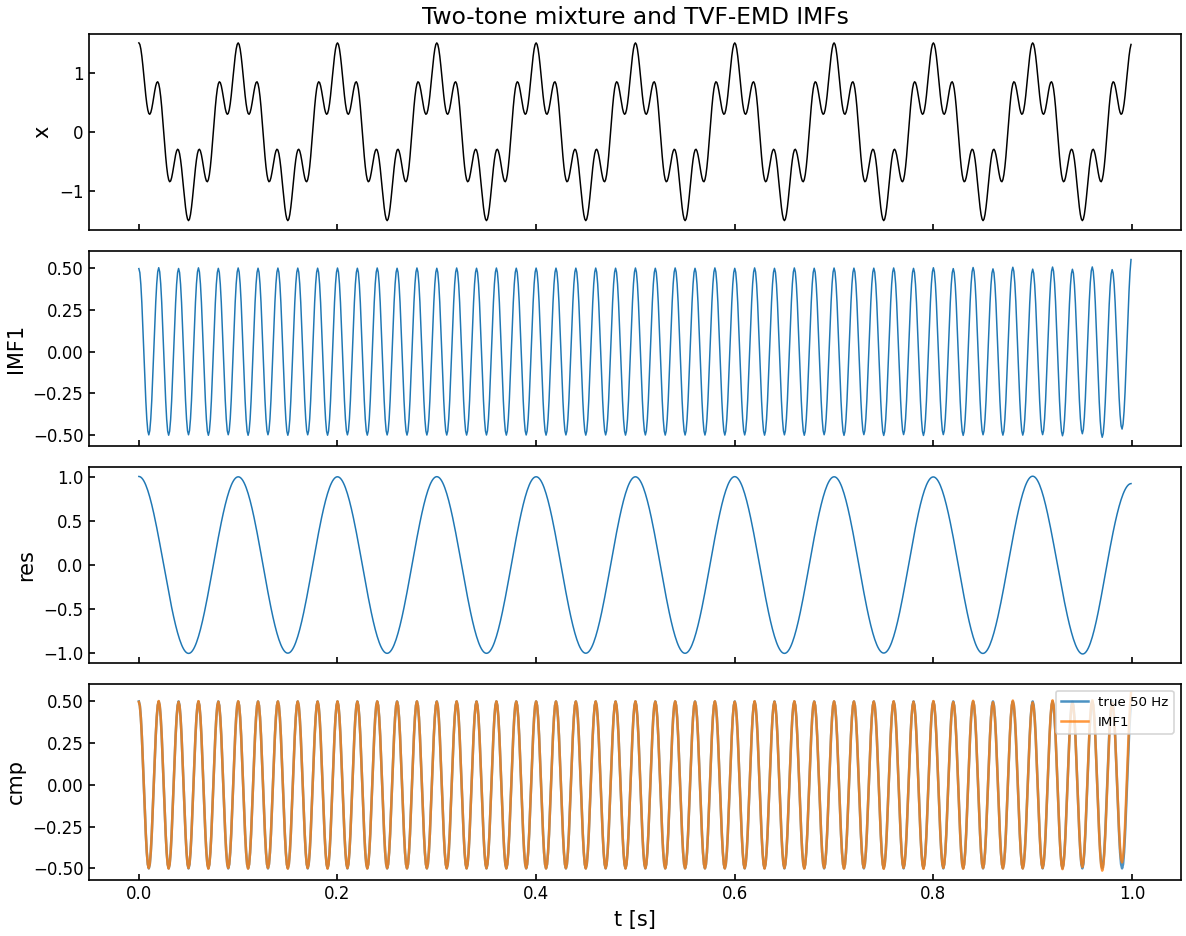

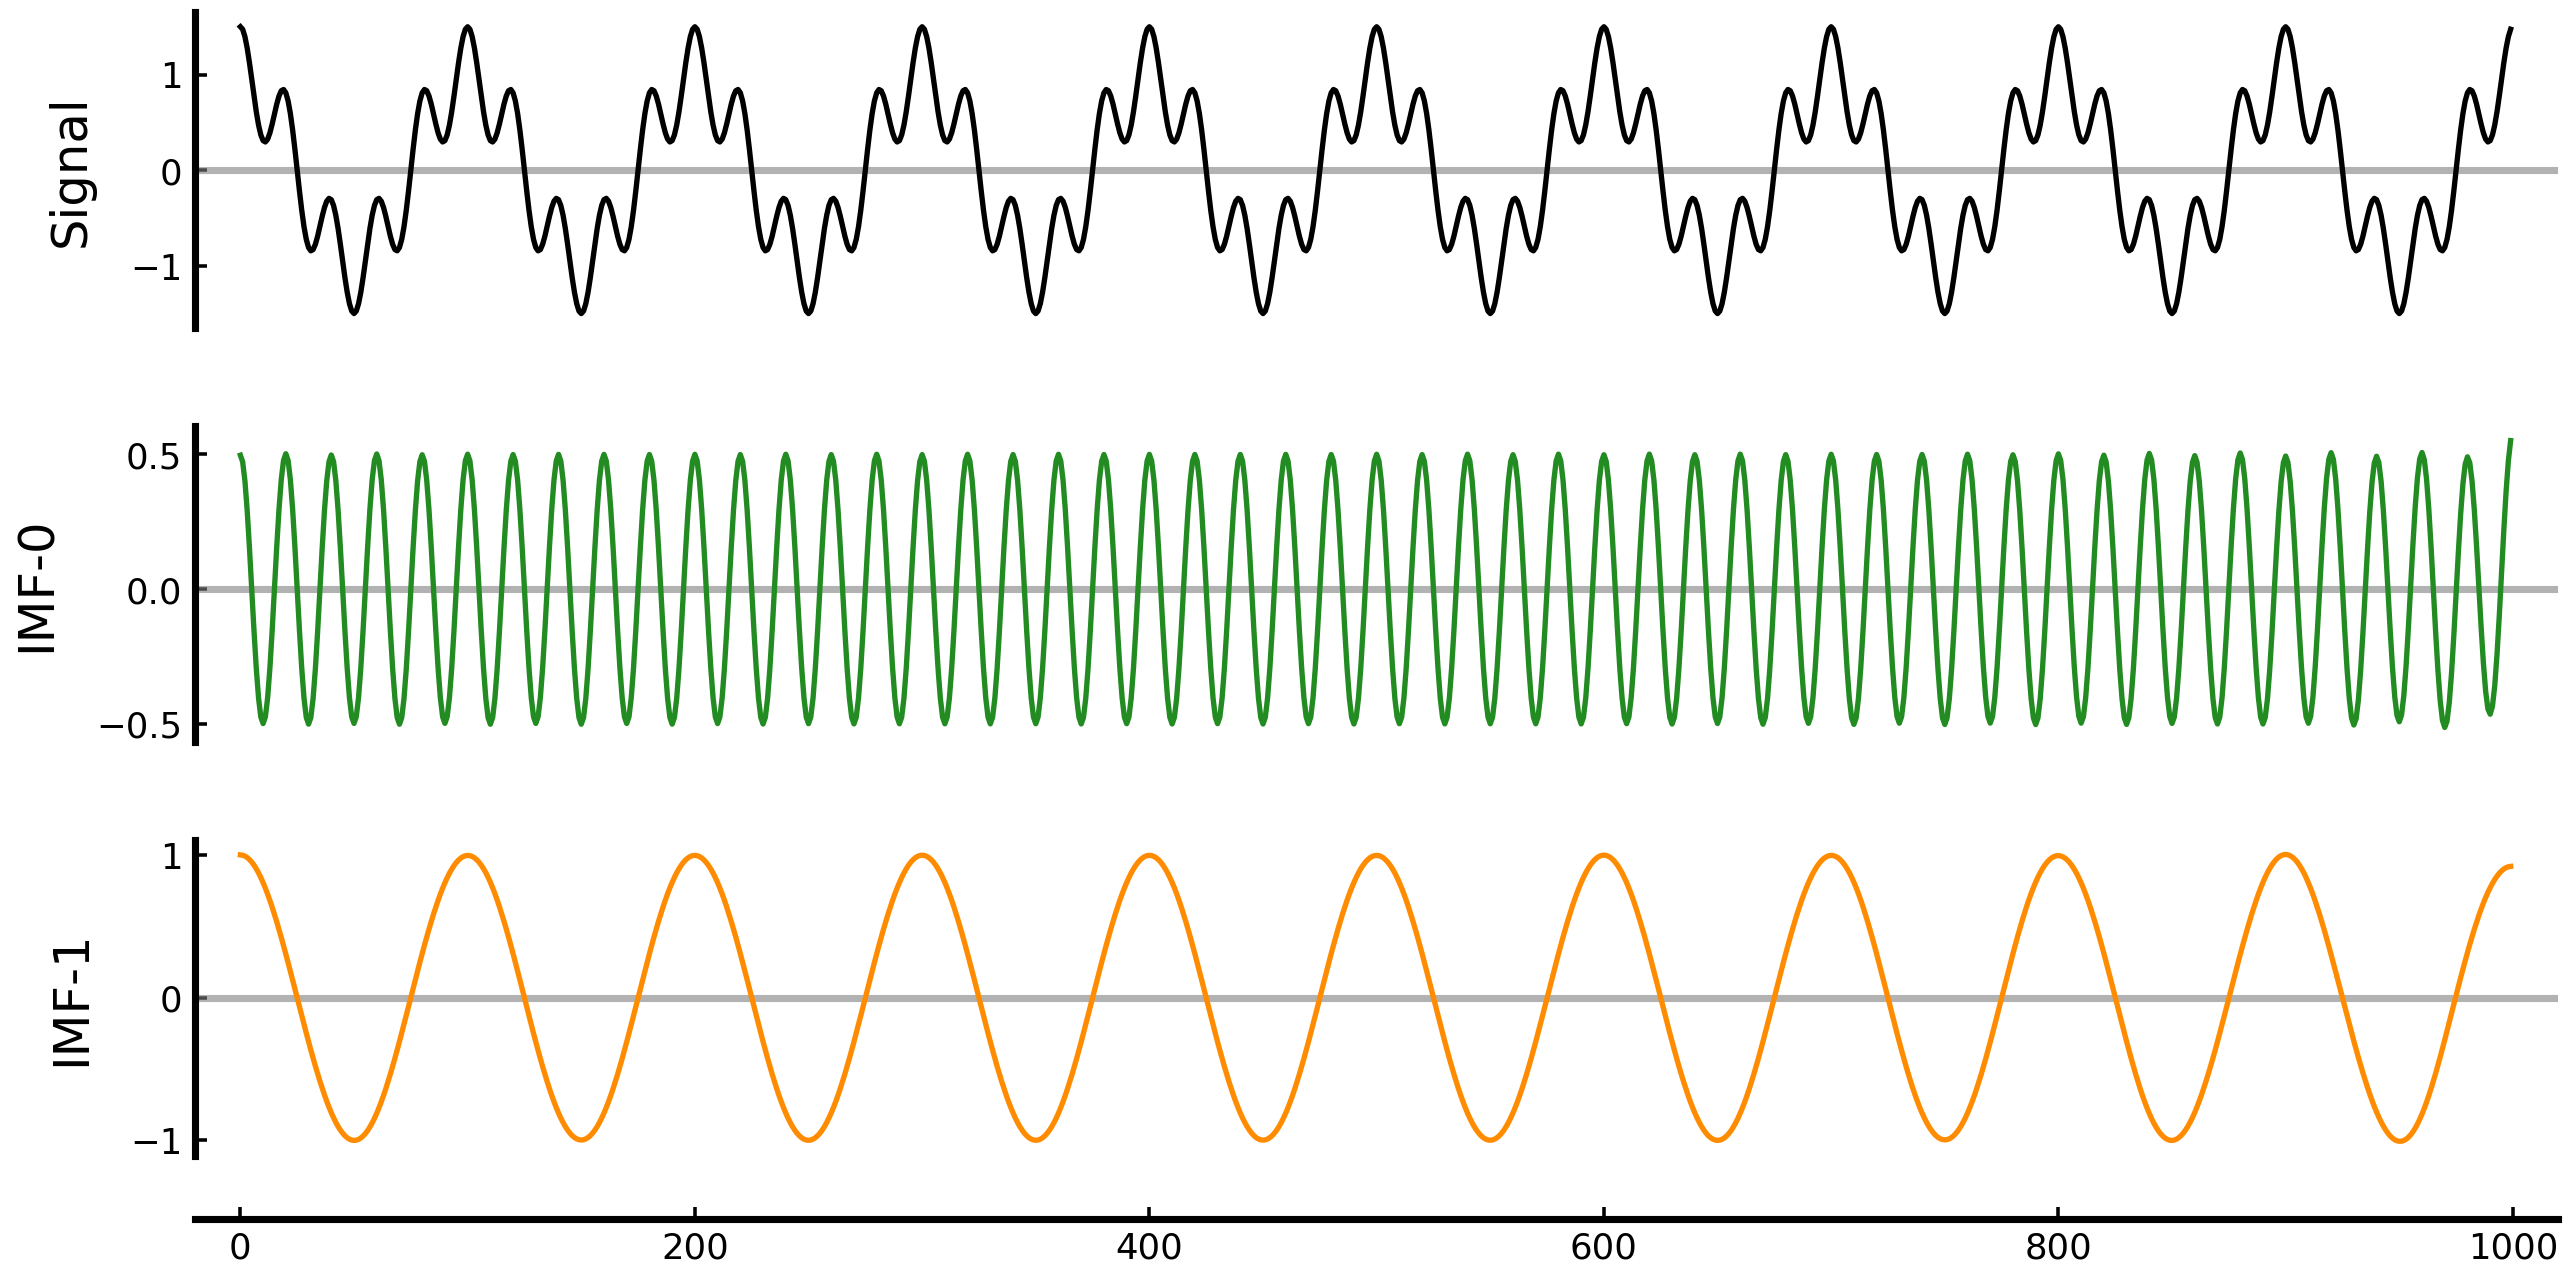

run classic


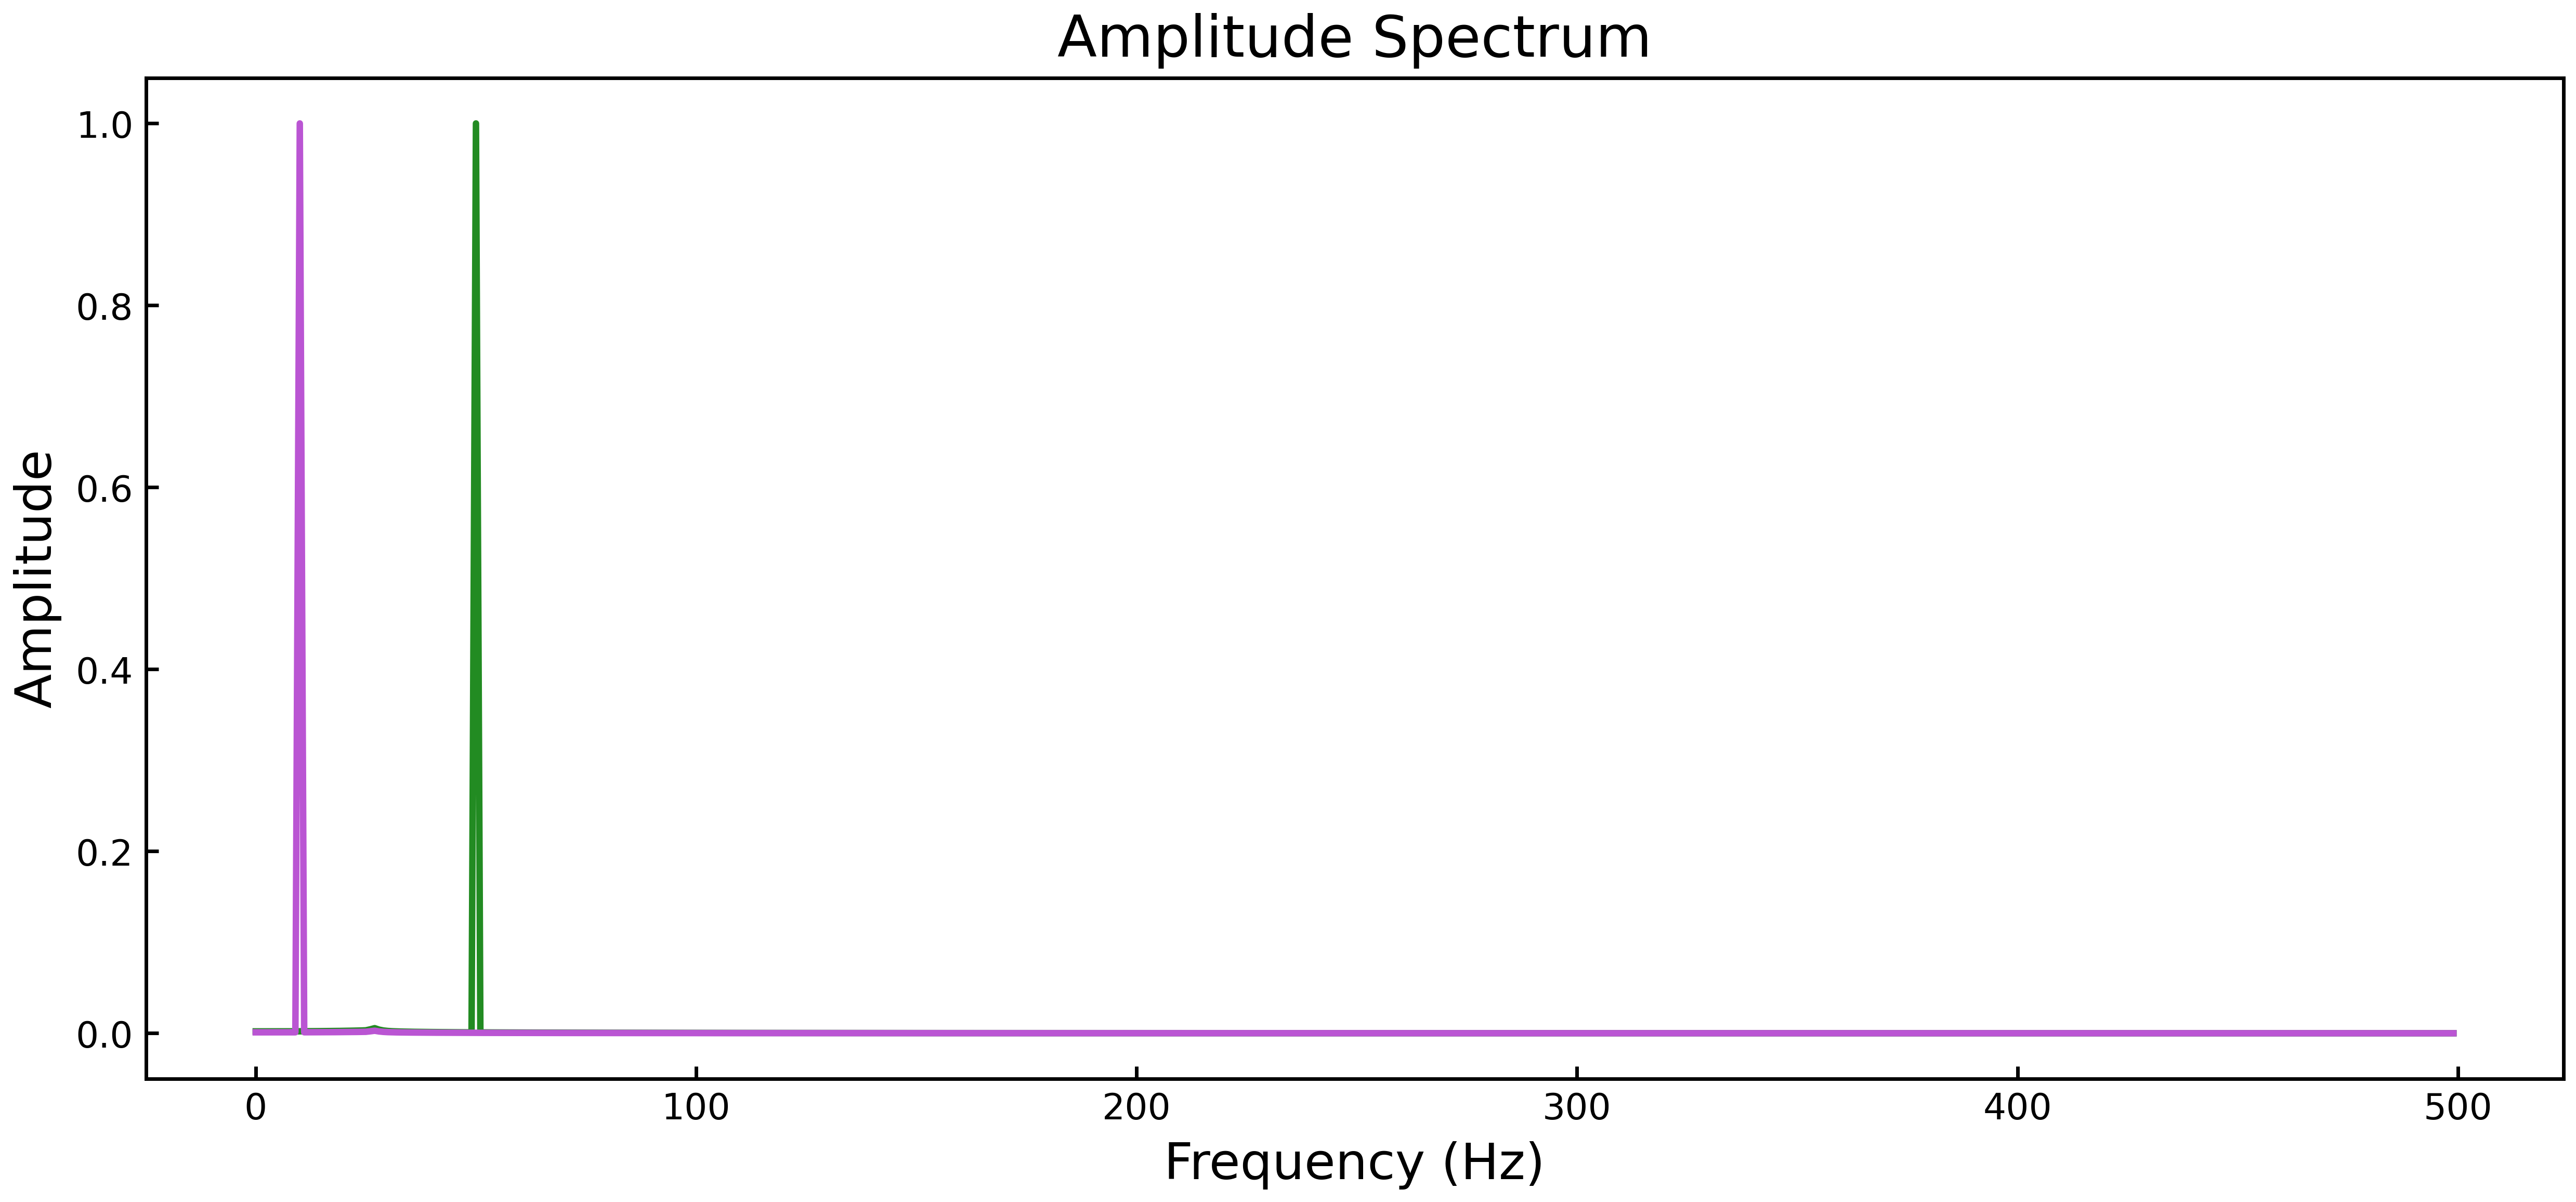

In [8]:
fs = 1000.0
t = np.arange(0, 1.0, 1.0 / fs)
s1 = np.cos(2 * np.pi * 10 * t)
s2 = 0.5 * np.cos(2 * np.pi * 50 * t)
x = s1 + s2

tvf = TVF_EMD(max_imf=5, thresh_bwr=0.1, bsp_order=26, max_iter=50)
imfs = tvf.fit_transform(x)

print("IMF shape:", imfs.shape)
print("Reconstruction max |error|:", np.max(np.abs(imfs.sum(0) - x)))

fig, axes = plt.subplots(imfs.shape[0] + 2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t, x, color="k", lw=0.9)
axes[0].set_ylabel("x")
axes[0].set_title("Two-tone mixture and TVF-EMD IMFs")
for k in range(imfs.shape[0]):
    axes[k + 1].plot(t, imfs[k], lw=0.9)
    axes[k + 1].set_ylabel(f"IMF{k+1}" if k < imfs.shape[0] - 1 else "res")
axes[-1].plot(t, s2, label="true 50 Hz", alpha=0.8)
axes[-1].plot(t, imfs[0], label="IMF1", alpha=0.8)
axes[-1].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("t [s]")
axes[-1].set_ylabel("cmp")
plt.tight_layout()
plt.show()

plot_IMFs(x, imfs)
plt.show()
plot_IMFs_amplitude_spectra(imfs, norm=True)
plt.show()

## 4. Example B -- close frequencies (mode-mixing stress test)

Classical EMD often mixes tones whose ratio lies within an octave (the
**separation problem** in Section 2.1; Huang's empirical cut-off is $\approx 0.65$).
Here $24/36=0.67$.  TVF-EMD's analytic $\varphi'_\mathrm{bis}$ is built exactly
for this case -- compare IMF1 against the 36 Hz tone and IMF2 against 24 Hz.


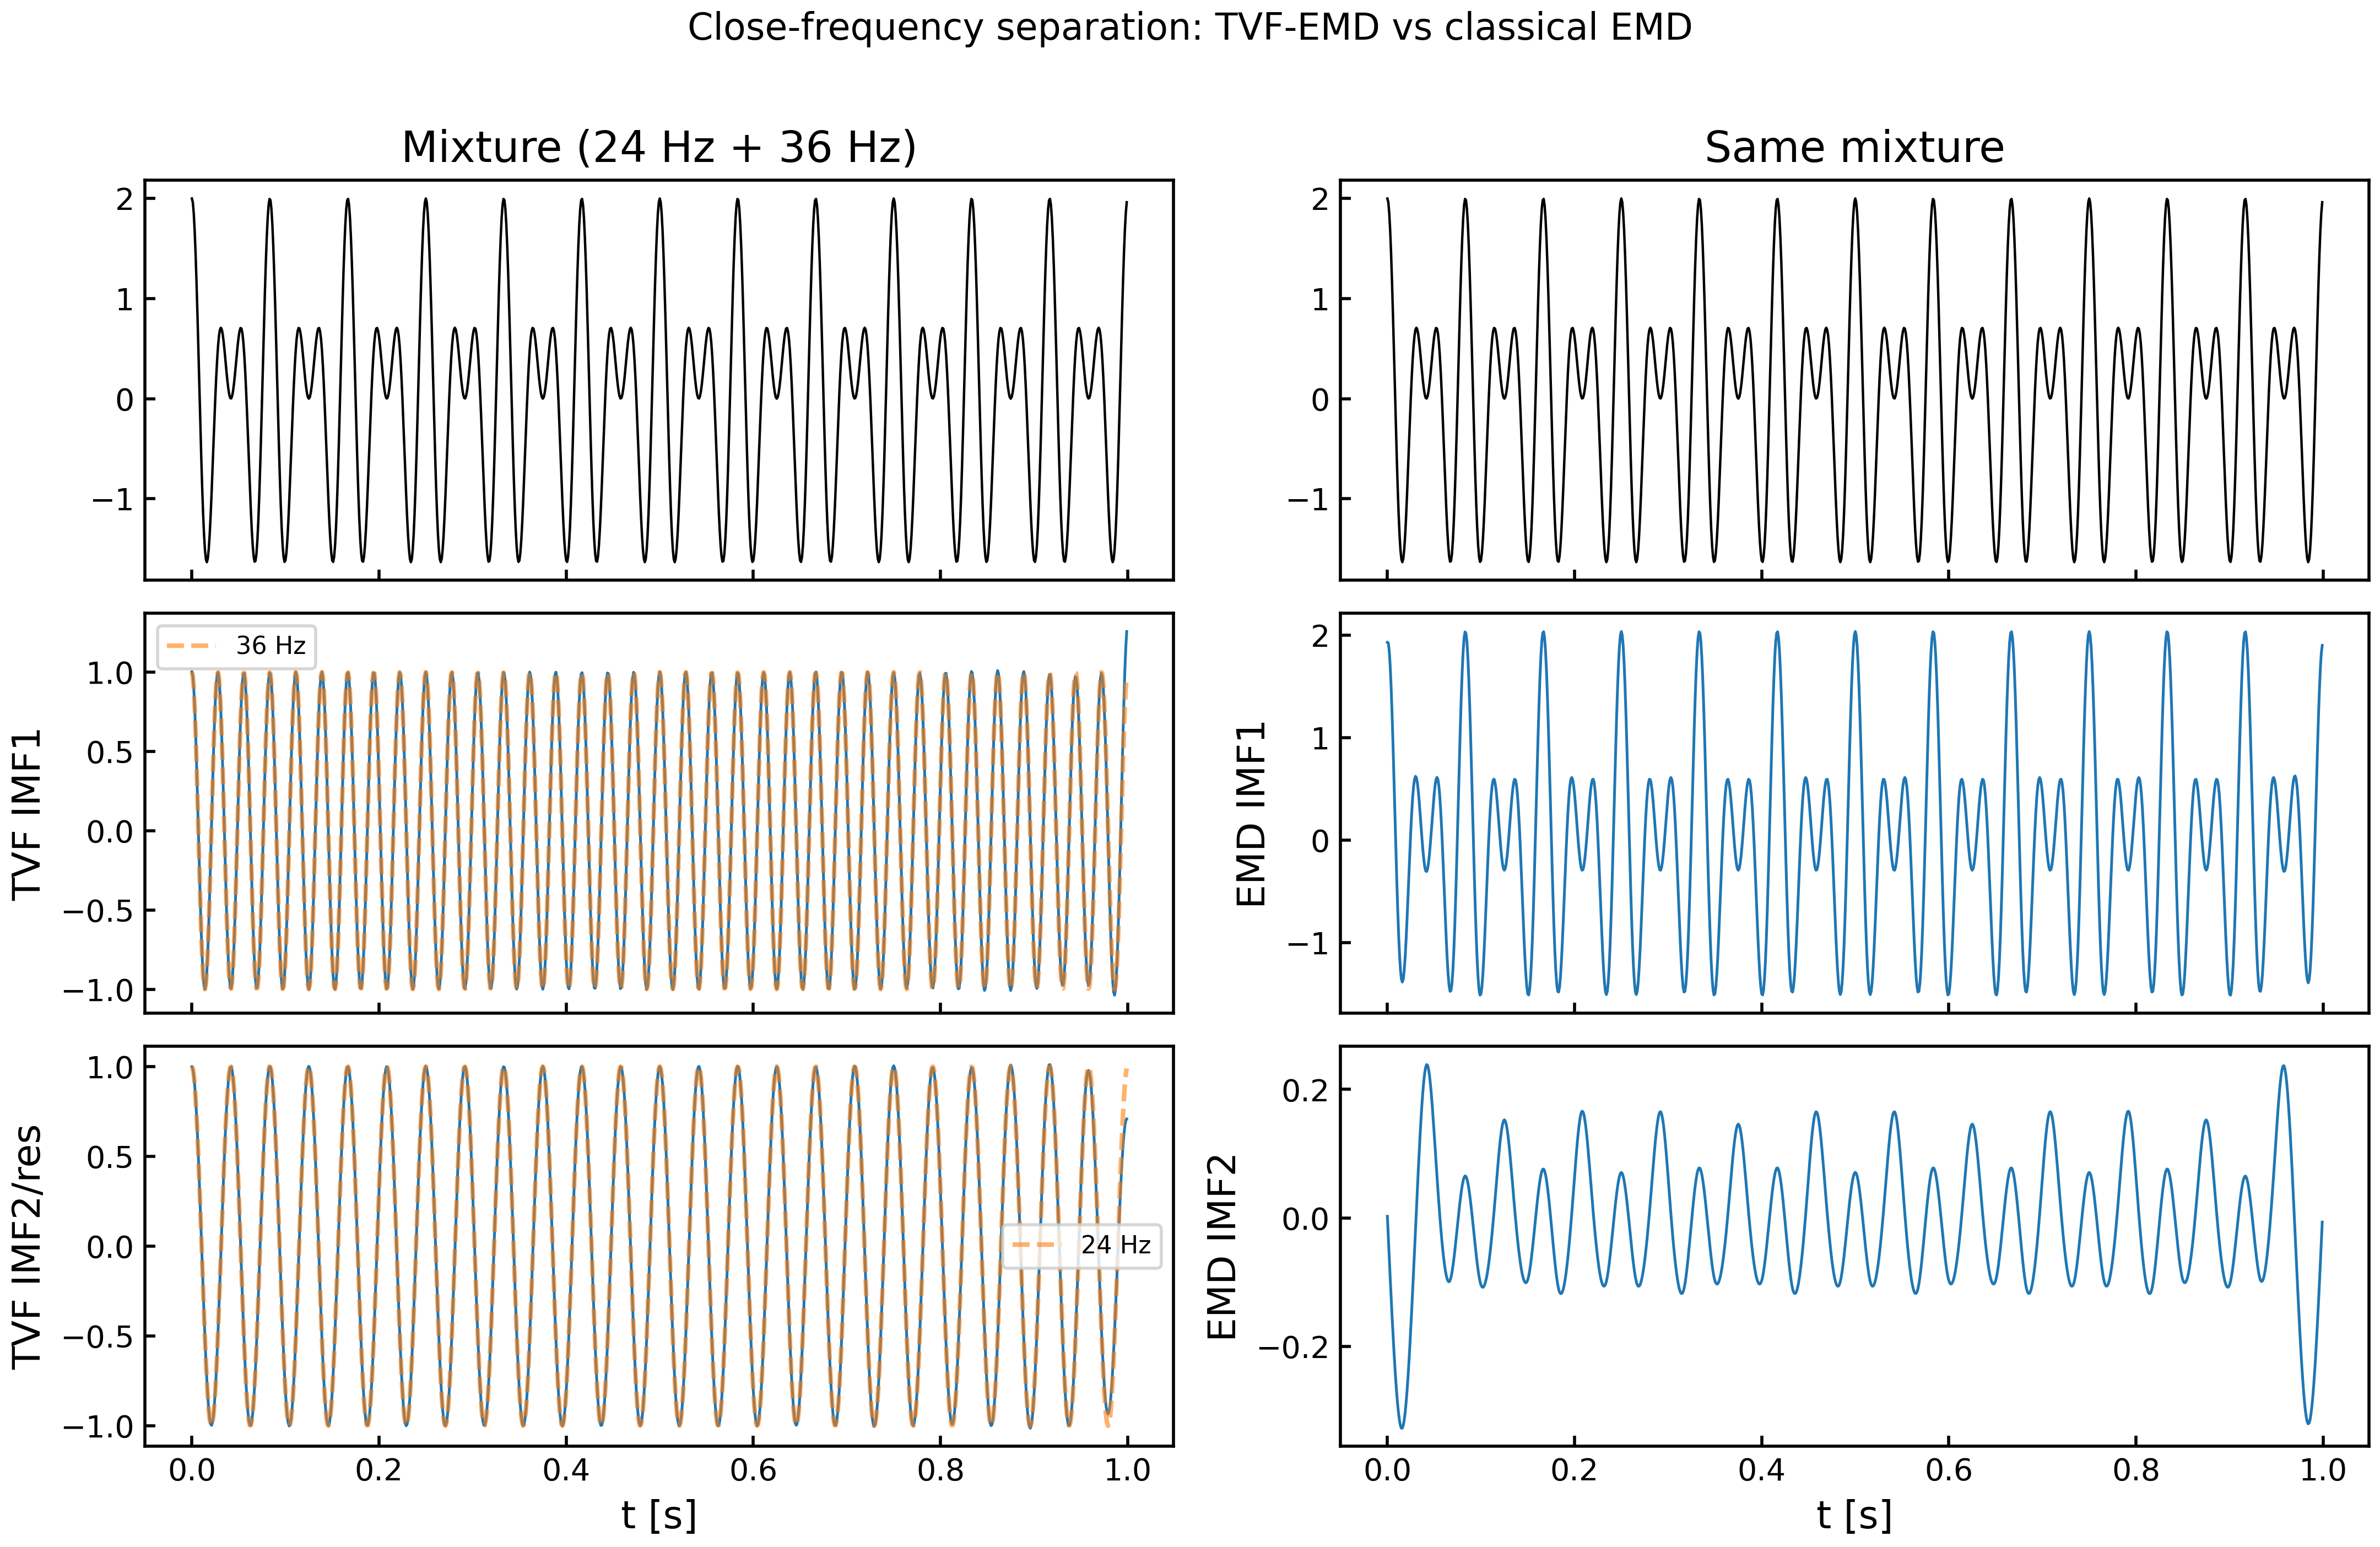

TVF recon err: 0.0
EMD recon err: 0.0


In [9]:
fs = 1000.0
t = np.arange(0, 1.0, 1.0 / fs)
c1 = np.cos(2 * np.pi * 24 * t)
c2 = np.cos(2 * np.pi * 36 * t)
x_close = c1 + c2

imfs_tvf = TVF_EMD(max_imf=4, thresh_bwr=0.1, max_iter=60).fit_transform(x_close)
imfs_emd = EMD(max_imfs=3).fit_transform(x_close)

fig, axes = plt.subplots(3, 2, figsize=(11, 7), sharex=True)
axes[0, 0].plot(t, x_close, color="k", lw=0.8)
axes[0, 0].set_title("Mixture (24 Hz + 36 Hz)")
axes[0, 1].plot(t, x_close, color="k", lw=0.8)
axes[0, 1].set_title("Same mixture")

axes[1, 0].plot(t, imfs_tvf[0], lw=0.9)
axes[1, 0].plot(t, c2, "--", alpha=0.6, label="36 Hz")
axes[1, 0].set_ylabel("TVF IMF1")
axes[1, 0].legend(fontsize=8)
axes[2, 0].plot(t, imfs_tvf[min(1, imfs_tvf.shape[0] - 1)], lw=0.9)
axes[2, 0].plot(t, c1, "--", alpha=0.6, label="24 Hz")
axes[2, 0].set_ylabel("TVF IMF2/res")
axes[2, 0].legend(fontsize=8)
axes[2, 0].set_xlabel("t [s]")

axes[1, 1].plot(t, imfs_emd[0], lw=0.9)
axes[1, 1].set_ylabel("EMD IMF1")
axes[2, 1].plot(t, imfs_emd[min(1, imfs_emd.shape[0] - 1)], lw=0.9)
axes[2, 1].set_ylabel("EMD IMF2")
axes[2, 1].set_xlabel("t [s]")

fig.suptitle("Close-frequency separation: TVF-EMD vs classical EMD", y=1.01)
plt.tight_layout()
plt.show()

print("TVF recon err:", np.max(np.abs(imfs_tvf.sum(0) - x_close)))
print("EMD recon err:", np.max(np.abs(imfs_emd.sum(0) - x_close)))

## 5. Example C -- intermittent high-frequency bursts

Intermittency is the other classical source of mode mixing (Section 2.4 / paper
Fig. 3).  A 5 Hz carrier is interrupted by sparse 80 Hz packets.  Cut-off
realignment (`anti_modemixing`, $\rho=0.25$) should keep the slow carrier from
being chopped into the burst IMF.


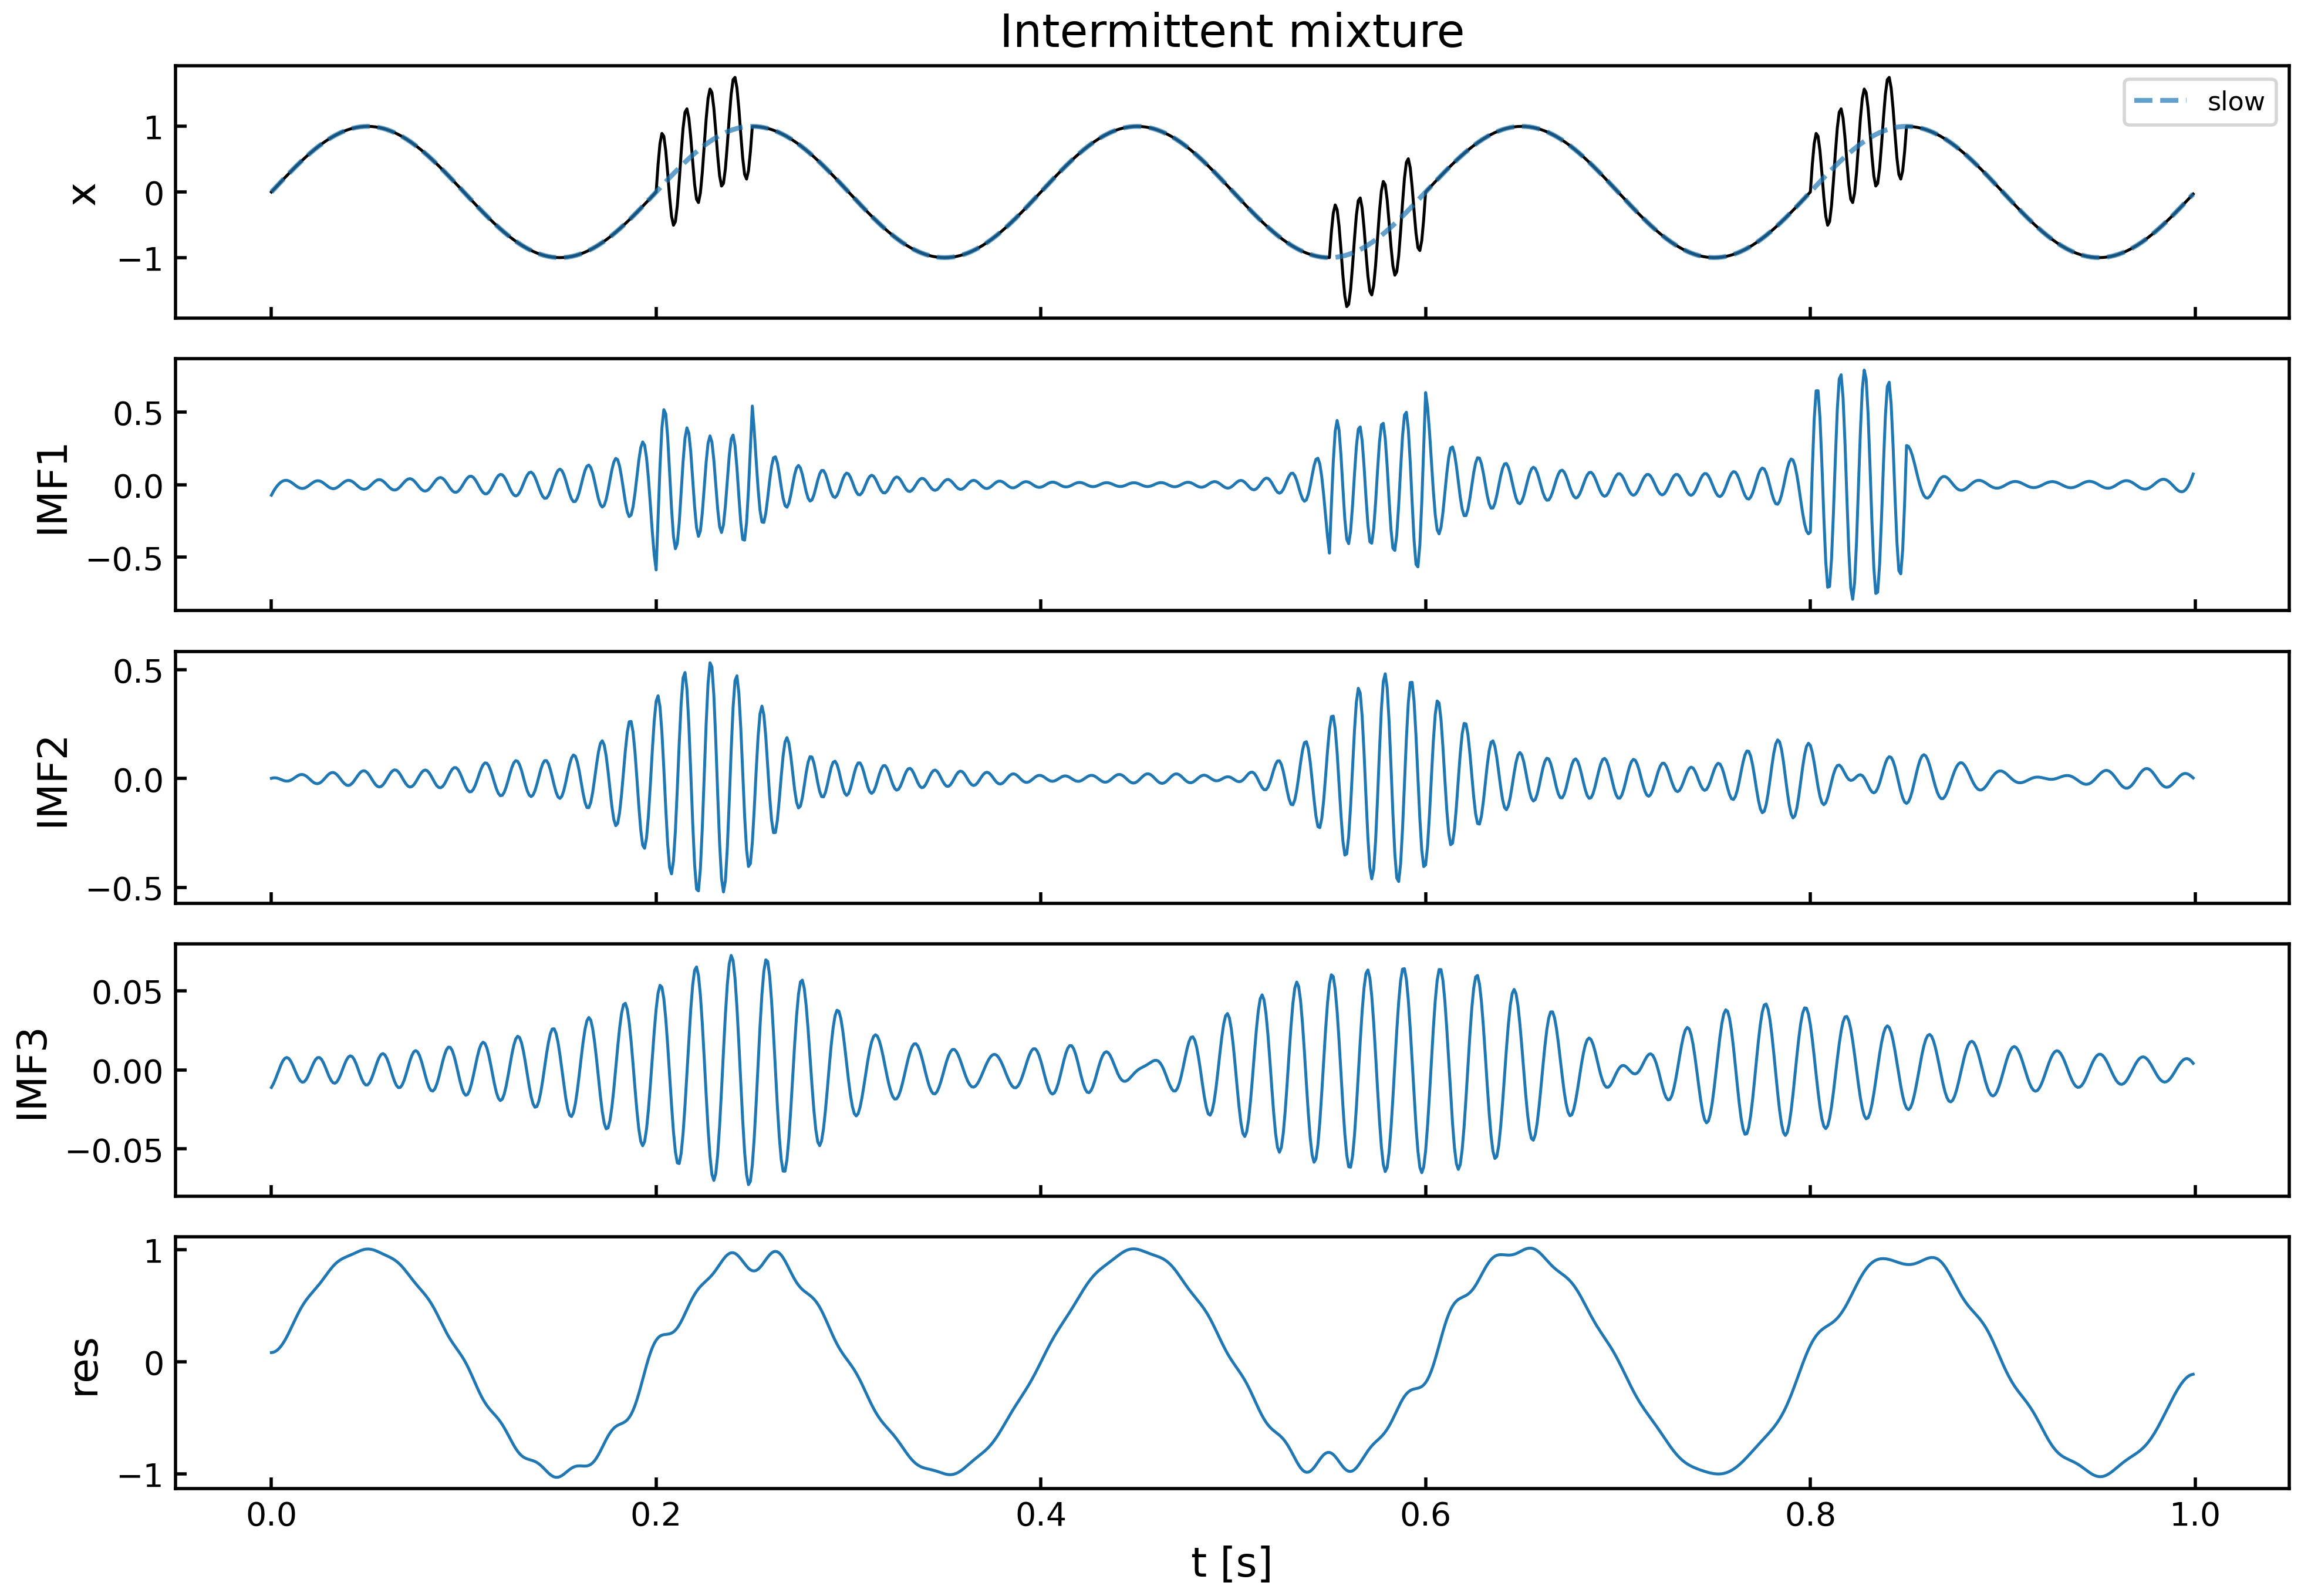

Reconstruction max |error|: 2.220446049250313e-16


In [10]:
fs = 1000.0
t = np.arange(0, 1.0, 1.0 / fs)
slow = np.sin(2 * np.pi * 5 * t)
burst = np.zeros_like(t)
for t0 in (0.2, 0.55, 0.8):
    mask = (t >= t0) & (t < t0 + 0.05)
    burst[mask] = 0.8 * np.sin(2 * np.pi * 80 * (t[mask] - t0))
x_int = slow + burst

imfs_int = TVF_EMD(max_imf=4, thresh_bwr=0.1, max_iter=50).fit_transform(x_int)

fig, axes = plt.subplots(imfs_int.shape[0] + 1, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, x_int, color="k", lw=0.9)
axes[0].plot(t, slow, "--", alpha=0.7, label="slow")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Intermittent mixture")
axes[0].set_ylabel("x")
for k in range(imfs_int.shape[0]):
    axes[k + 1].plot(t, imfs_int[k], lw=0.9)
    axes[k + 1].set_ylabel(f"IMF{k+1}" if k < imfs_int.shape[0] - 1 else "res")
axes[-1].set_xlabel("t [s]")
plt.tight_layout()
plt.show()

print("Reconstruction max |error|:", np.max(np.abs(imfs_int.sum(0) - x_int)))

## 6. Example D -- AM-FM component + chirp

Non-stationary components as in the paper's AM-FM / chirp illustrations.  Because
the B-spline cut-off is **time-varying**, a chirp is a natural test: extrema of
$h=\cos\int\varphi'_\mathrm{bis}$ should track the instantaneous mid-frequency
rather than a constant filter bank (the EEMD contrast in Section 2.4).


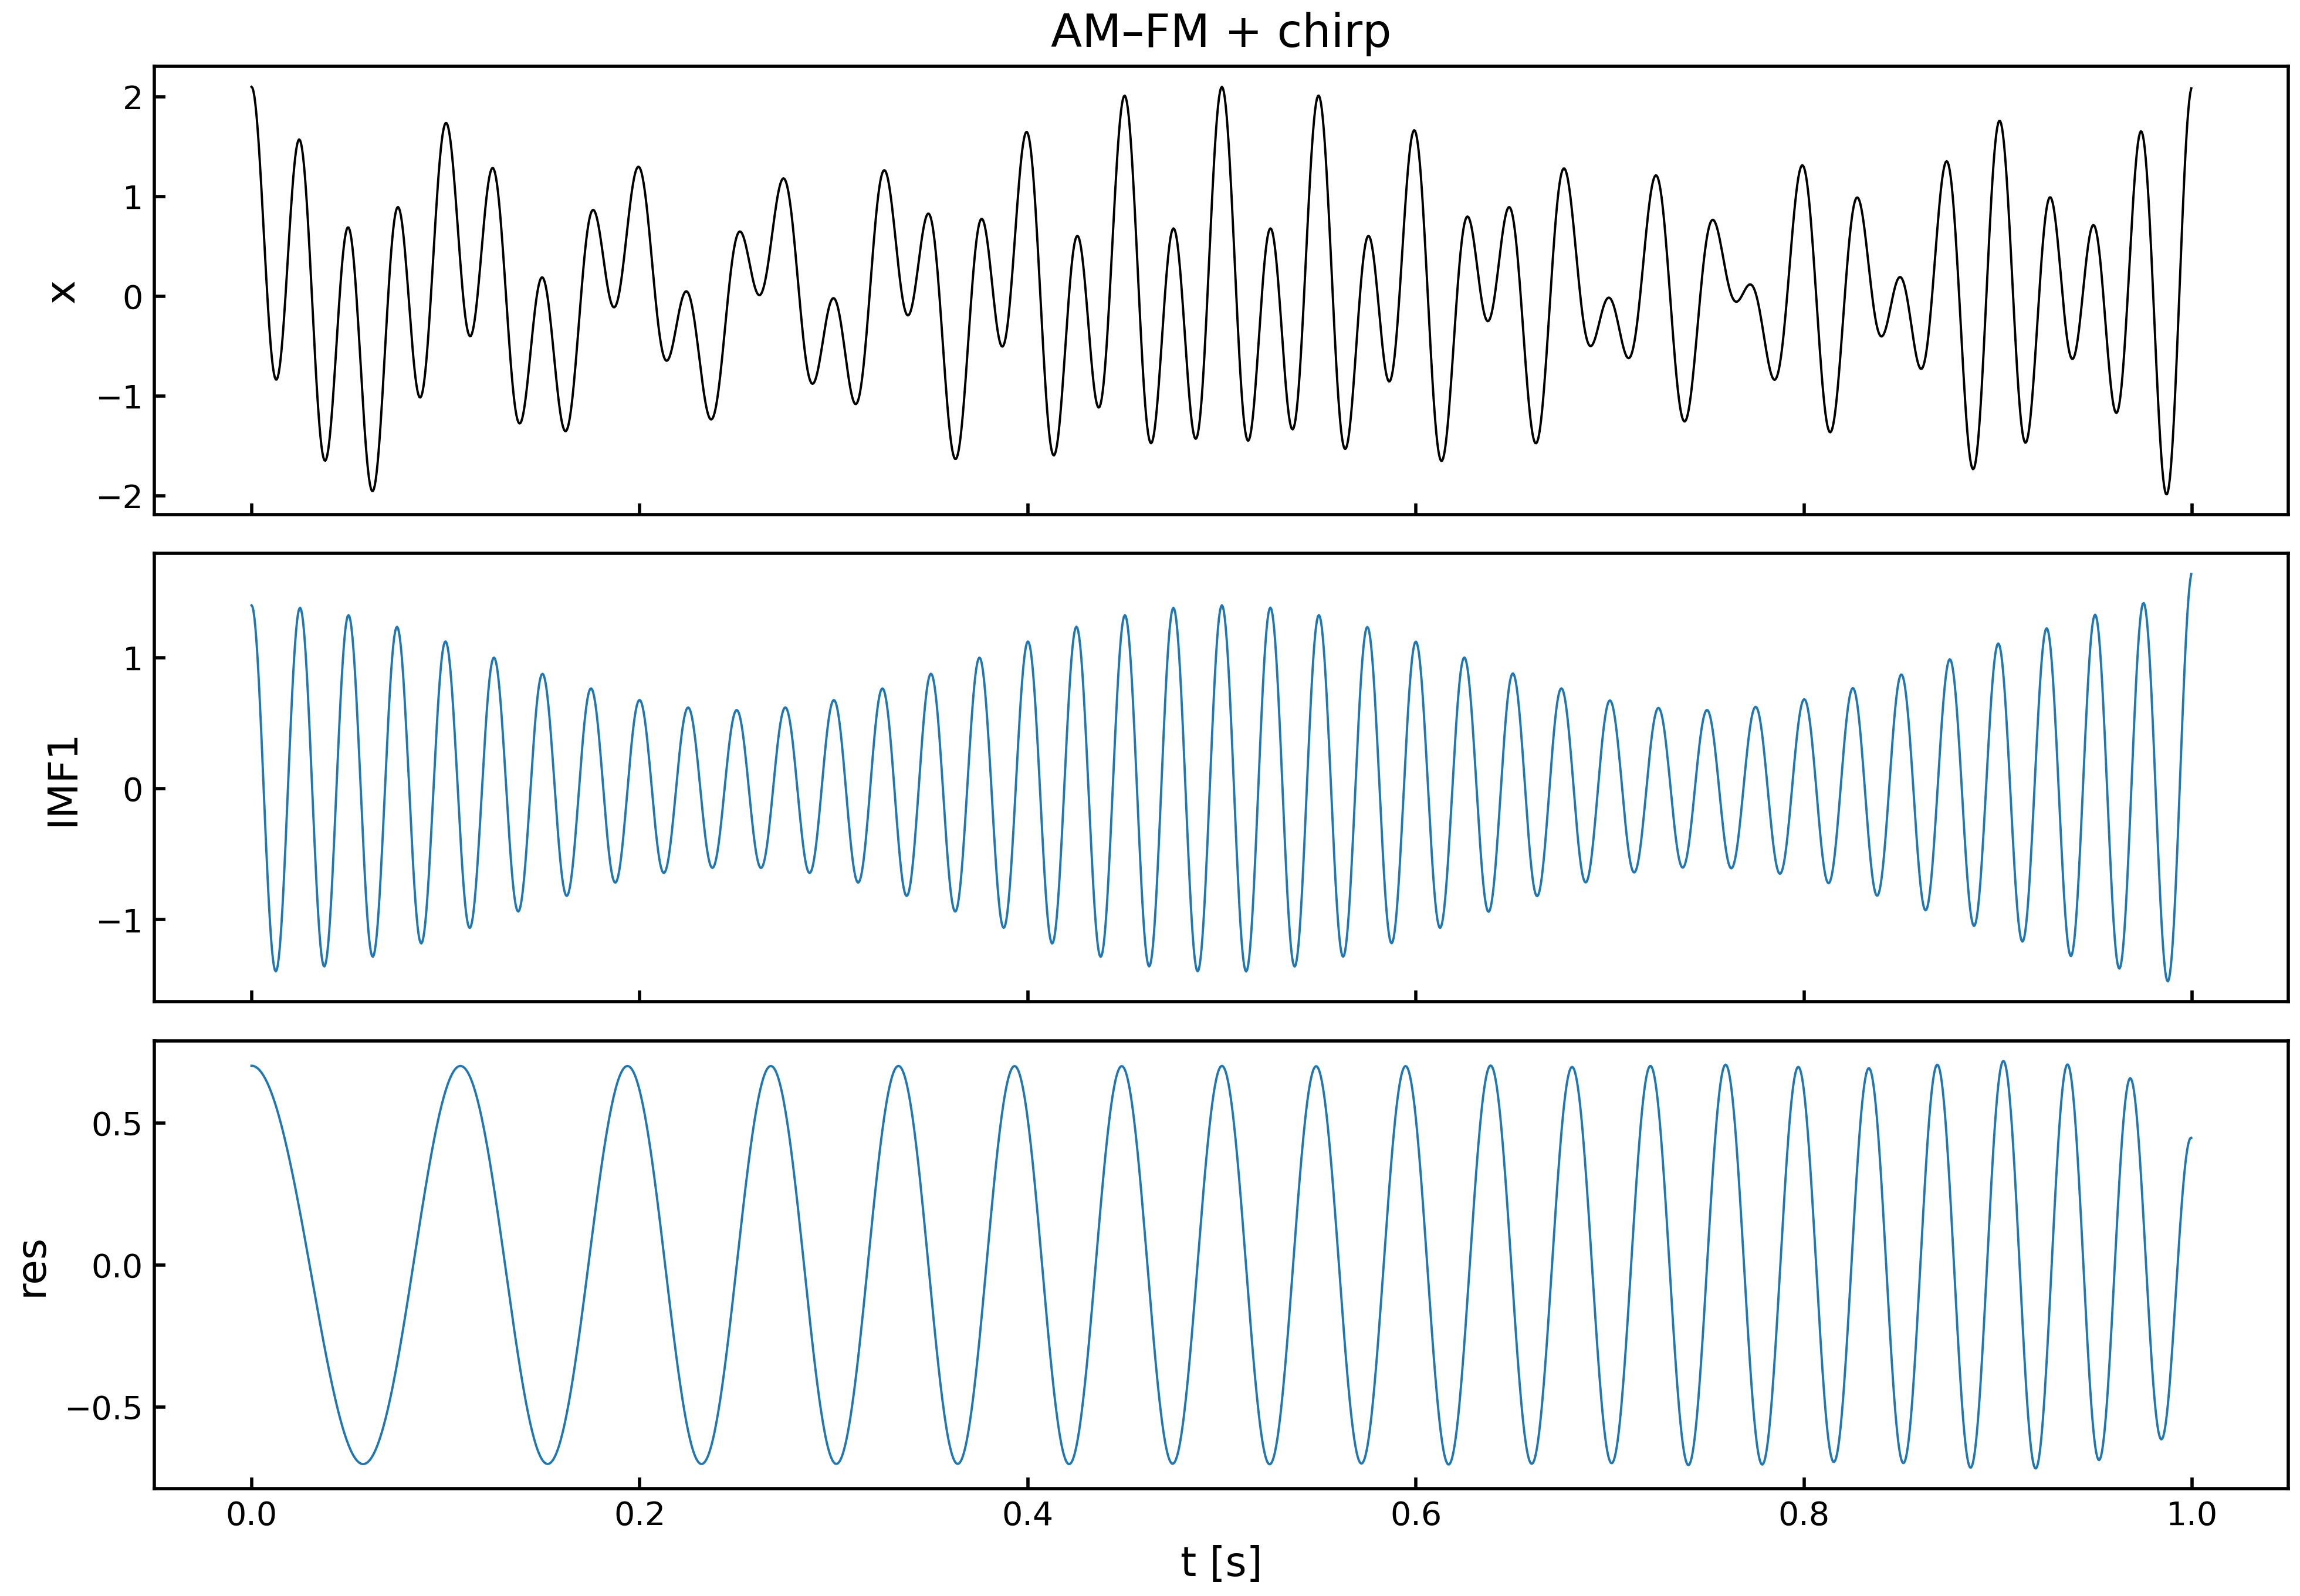

Reconstruction max |error|: 0.0


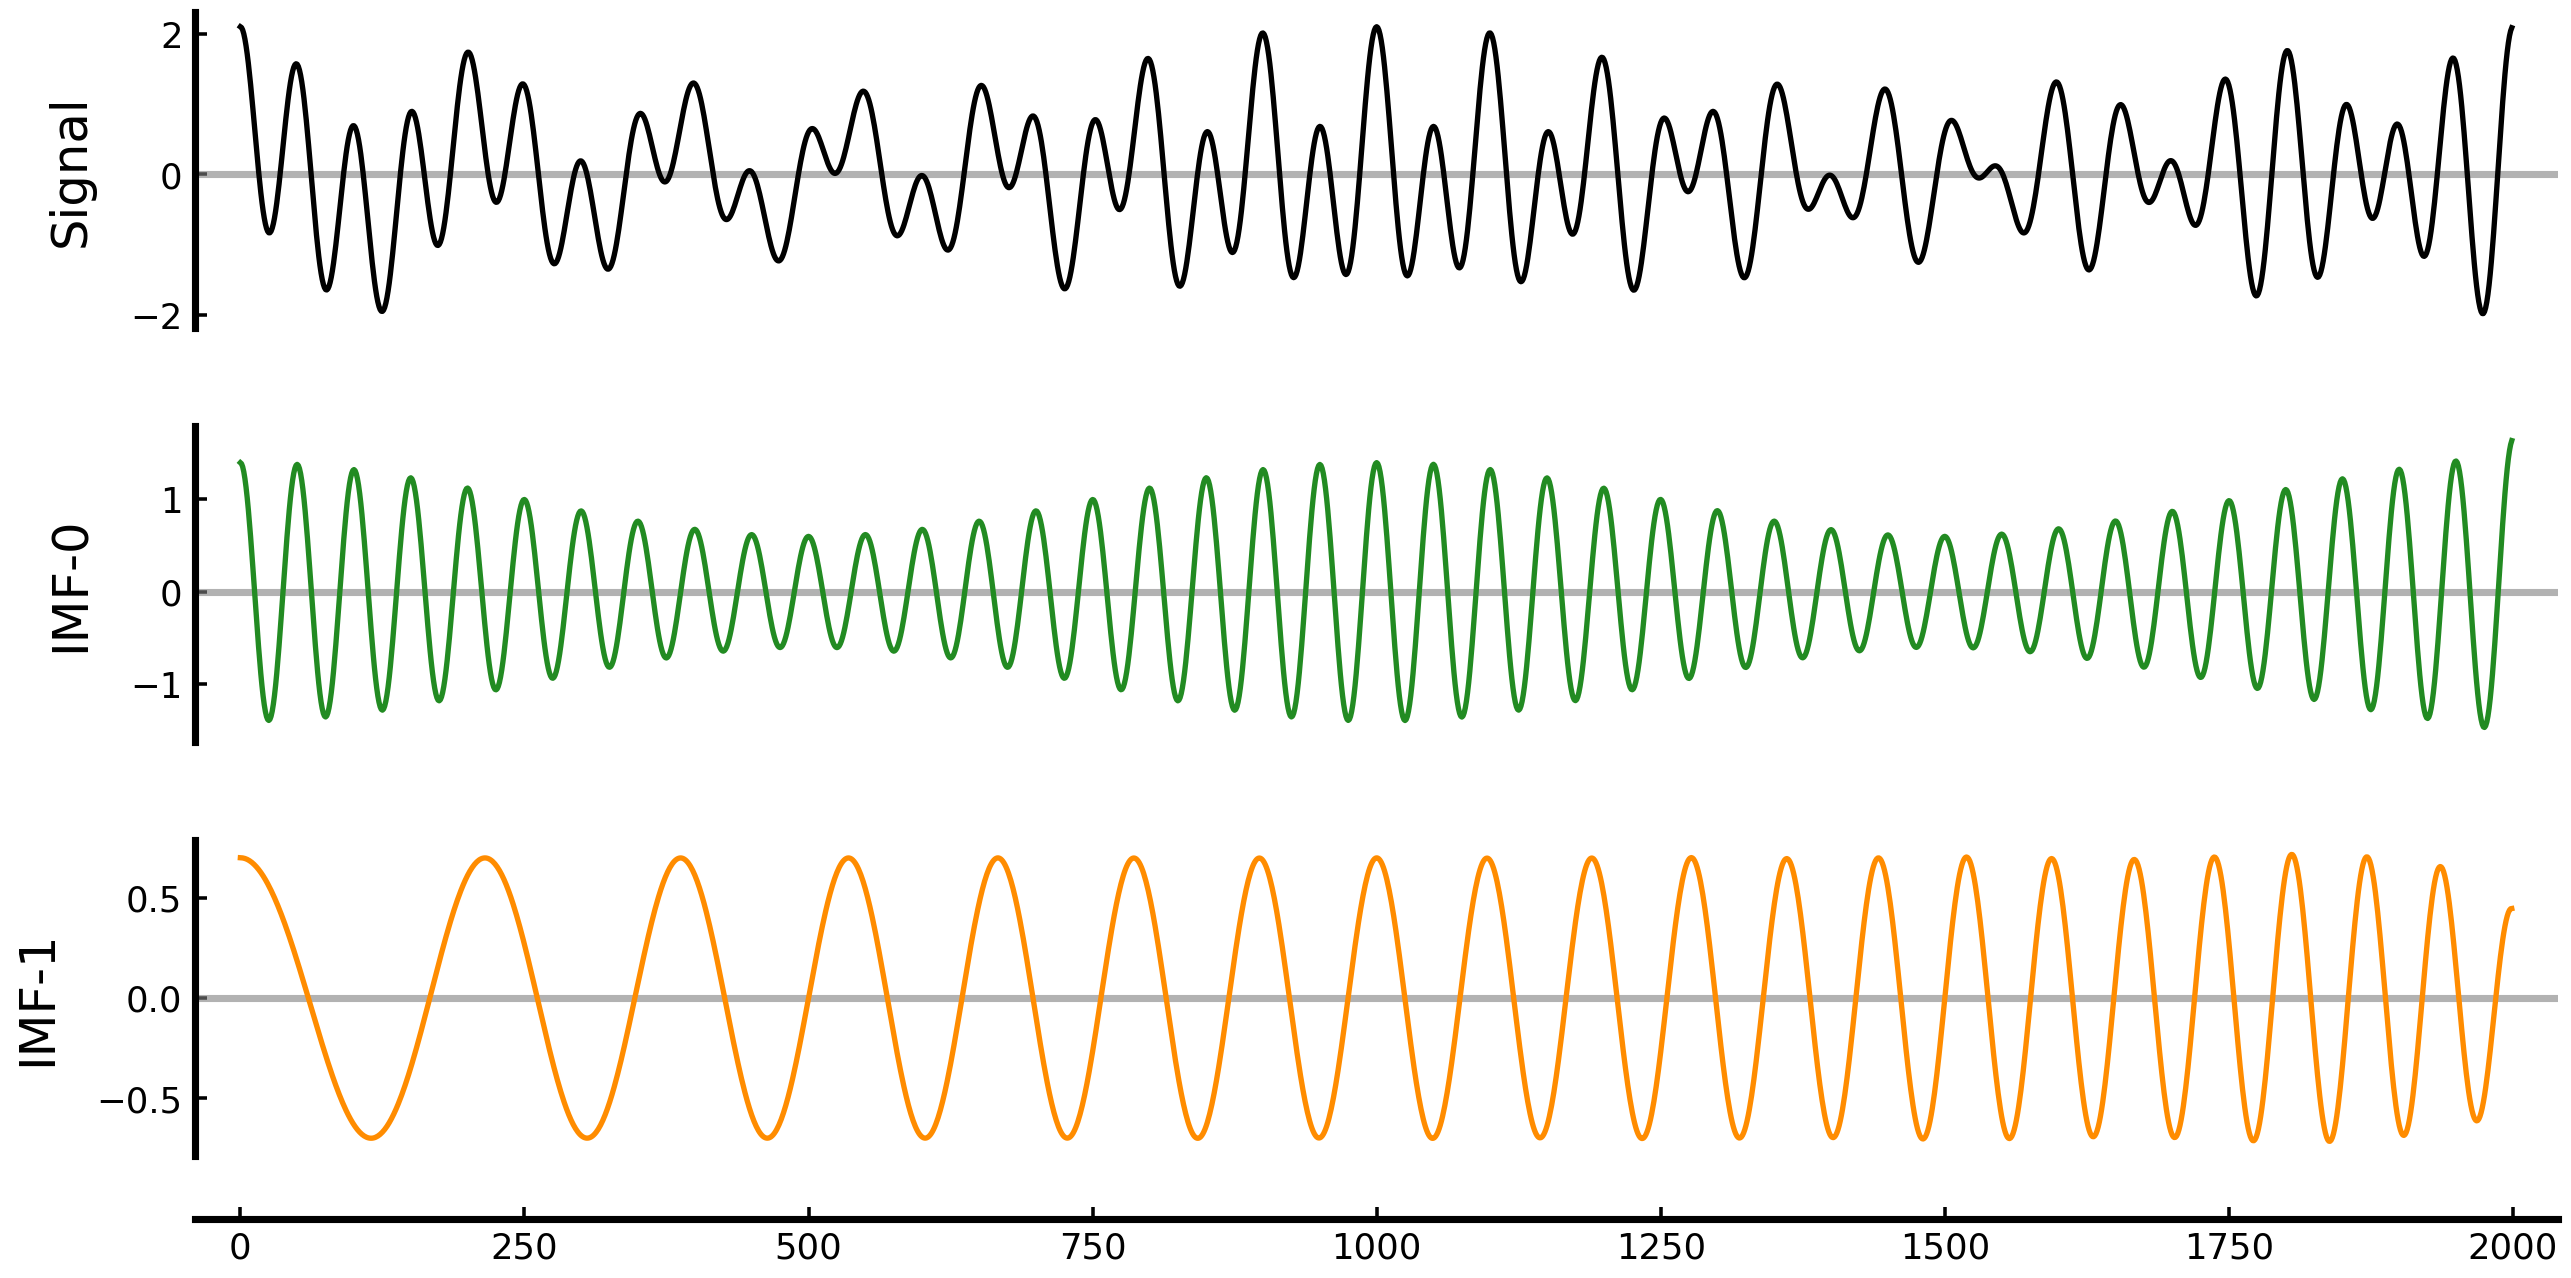

In [11]:
fs = 2000.0
t = np.arange(0, 1.0, 1.0 / fs)
amfm = (1.0 + 0.4 * np.cos(2 * np.pi * 2 * t)) * np.cos(2 * np.pi * 40 * t)
chirp = 0.7 * np.cos(2 * np.pi * (8 * t + 12 * t**2))
x_ns = amfm + chirp

imfs_ns = TVF_EMD(max_imf=4, thresh_bwr=0.1, bsp_order=26, max_iter=60).fit_transform(
    x_ns
)

fig, axes = plt.subplots(imfs_ns.shape[0] + 1, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, x_ns, color="k", lw=0.7)
axes[0].set_title("AM–FM + chirp")
axes[0].set_ylabel("x")
for k in range(imfs_ns.shape[0]):
    axes[k + 1].plot(t, imfs_ns[k], lw=0.7)
    axes[k + 1].set_ylabel(f"IMF{k+1}" if k < imfs_ns.shape[0] - 1 else "res")
axes[-1].set_xlabel("t [s]")
plt.tight_layout()
plt.show()

print("Reconstruction max |error|:", np.max(np.abs(imfs_ns.sum(0) - x_ns)))
plot_IMFs(x_ns, imfs_ns)
plt.show()

## 7. Quick API check

`TVF_EMD` instances are callable; `__str__` reports the algorithm name.

In [12]:
decomp = TVF_EMD(max_imf=3, max_iter=20)
y = np.cos(2 * np.pi * np.linspace(0, 5, 400))
out = decomp(y)
print(decomp)
print("callable output shape:", out.shape)
assert np.allclose(out.sum(0), y)

Time Varying Filter based Empirical Mode Decomposition (TVF_EMD)
callable output shape: (1, 400)
